# GMM Noise Extension on the Prebuilt Noise-Induced ILPD Dataset

This notebook is the second-phase contribution notebook for the project **"Uncertainty-Aware Liver Cirrhosis Classification under Noisy and Outlier-Rich Clinical Data"**.

It now starts directly from the **already generated robust-scaled + GMM-noisy ILPD dataset** and focuses on:

- loading the prebuilt noisy modeling table without recreating noise from the cleaned dataset
- evaluating the clean-literature benchmark on that same noisy dataset
- comparing the standardized notebook pipeline against the workflow in `final_models.ipynb`
- tuning the strongest noisy-data candidates with focused **three-hyperparameter** searches

The goal is to keep Notebook 06 honest to the noisy-data setting while making it easier to see why its results still differ from `final_models.ipynb`.


In [1]:
import json
import os
import warnings
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "1")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import ExtraTreesClassifier, GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
    XGBOOST_IMPORT_ERROR = None
except Exception as exc:
    XGBClassifier = None
    XGBOOST_AVAILABLE = False
    XGBOOST_IMPORT_ERROR = repr(exc)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
CV_SPLITS = 5
TEST_SIZE = 0.20
N_JOBS = 1

np.random.seed(RANDOM_STATE)
pd.options.display.float_format = "{:.4f}".format
plt.style.use("default")


def resolve_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists() or (candidate / ".git").exists():
            return candidate
    raise FileNotFoundError("Could not locate repository root from the current working directory.")


ROOT = resolve_repo_root(Path.cwd())
DATASET_PATH = ROOT / "data" / "processed" / "ILPD_robust_scaled_with_gmm_noise.csv"
LITERATURE_RESULTS_PATH = ROOT / "output" / "literature_recreation_cleaned_ilpd.csv"
RESULTS_PATH = ROOT / "output" / "gmm_noise_extension_results_ilpd.csv"
FINAL_MODELS_NOTEBOOK_PATH = ROOT / "scripts" / "final_models.ipynb"
RESULTS_PATH.parent.mkdir(parents=True, exist_ok=True)

print(
    {
        "dataset_path": str(DATASET_PATH),
        "literature_results_path": str(LITERATURE_RESULTS_PATH),
        "results_output_path": str(RESULTS_PATH),
        "final_models_notebook_path": str(FINAL_MODELS_NOTEBOOK_PATH),
        "xgboost_available": XGBOOST_AVAILABLE,
    }
)


{'dataset_path': '/Users/samyabrataroy/Downloads/Spring_Internship_2026/data/processed/ILPD_robust_scaled_with_gmm_noise.csv', 'literature_results_path': '/Users/samyabrataroy/Downloads/Spring_Internship_2026/output/literature_recreation_cleaned_ilpd.csv', 'results_output_path': '/Users/samyabrataroy/Downloads/Spring_Internship_2026/output/gmm_noise_extension_results_ilpd.csv', 'final_models_notebook_path': '/Users/samyabrataroy/Downloads/Spring_Internship_2026/scripts/final_models.ipynb', 'xgboost_available': True}


## 1. Load the Prebuilt Noise-Induced ILPD Dataset

Notebook 06 now starts from the existing `ILPD_robust_scaled_with_gmm_noise.csv` artifact. The `Synthetic_Flag` column is preserved for auditing, but it is excluded from model features so the notebook matches the feature handling in `final_models.ipynb`.


In [2]:
noise_df = pd.read_csv(DATASET_PATH)

TARGET_COLUMN = "Result"
AUDIT_COLUMNS = [column for column in ["Synthetic_Flag"] if column in noise_df.columns]
FEATURE_COLUMNS = [column for column in noise_df.columns if column not in [TARGET_COLUMN, *AUDIT_COLUMNS]]

data = noise_df.copy()
for column in FEATURE_COLUMNS:
    if data[column].dtype == object:
        if column == "Gender":
            gender_map = {"male": 1, "female": 0, "m": 1, "f": 0}
            data[column] = data[column].astype(str).str.strip().str.lower().map(gender_map)
        if data[column].dtype == object:
            data[column], _ = pd.factorize(data[column].astype(str))

X = data[FEATURE_COLUMNS].apply(pd.to_numeric, errors="coerce").copy()
y_raw = pd.to_numeric(data[TARGET_COLUMN], errors="coerce")

valid_mask = y_raw.notna()
data = data.loc[valid_mask].reset_index(drop=True)
X = X.loc[valid_mask].reset_index(drop=True)
y_raw = y_raw.loc[valid_mask].astype(int).reset_index(drop=True)

unexpected_labels = sorted(set(y_raw.unique()) - {1, 2})
if unexpected_labels:
    raise ValueError(f"Expected ILPD target labels {{1, 2}}, found extra labels: {unexpected_labels}")

# Match final_models.ipynb exactly: label 1 stays positive, label 2 becomes class 0.
y = y_raw.replace({1: 1, 2: 0}).astype(int)

modeling_df = X.copy()
modeling_df[TARGET_COLUMN] = y
for column in AUDIT_COLUMNS:
    modeling_df[column] = pd.to_numeric(data[column], errors="coerce").fillna(0).astype(int)

print(f"Dataset path: {DATASET_PATH}")
print(f"Dataset shape: {modeling_df.shape}")
print("Feature columns:", FEATURE_COLUMNS)
print("Audit columns:", AUDIT_COLUMNS)
print("Encoded target counts:", y.value_counts().sort_index().to_dict())
display(modeling_df.head())

if AUDIT_COLUMNS:
    audit_summary = pd.DataFrame(
        [
            {
                "audit_column": column,
                "value_counts": dict(modeling_df[column].value_counts(dropna=False).sort_index()),
            }
            for column in AUDIT_COLUMNS
        ]
    )
    display(audit_summary)


Dataset path: /Users/samyabrataroy/Downloads/Spring_Internship_2026/data/processed/ILPD_robust_scaled_with_gmm_noise.csv
Dataset shape: (684, 12)
Feature columns: ['Age', 'Gender', 'Total_Bilirubin', 'Direct_Bilirubin', 'Alkaline_Phosphotase', 'Alamine_Aminotransferase', 'Aspartate_Aminotransferase', 'Total_Proteins', 'Albumin', 'Albumin_and_Globulin_Ratio']
Audit columns: ['Synthetic_Flag']
Encoded target counts: {0: 197, 1: 487}


,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Proteins,Albumin,Albumin_and_Globulin_Ratio,Result,Synthetic_Flag
0,0.8000,1.0000,-0.1667,-0.1818,-0.1721,-0.5135,-0.3725,0.1429,0.1667,-0.1250,1,0
1,0.6800,0.0000,5.5000,4.7273,4.0246,0.7838,0.9555,0.6429,0.0833,-0.5250,1,0
2,0.6800,0.0000,3.5000,3.4545,2.3115,0.6757,0.4372,0.2857,0.1667,-0.1500,1,0
3,0.5200,0.0000,0.0000,0.0909,-0.2131,-0.5676,-0.3401,0.1429,0.2500,0.1250,1,0
4,1.0800,0.0000,1.6111,1.5455,-0.1066,-0.2162,0.2915,0.5000,-0.5833,-1.3750,1,0


,audit_column,value_counts
0,Synthetic_Flag,"{0: 570, 1: 114}"


## 2. Feature Audit and Variant Setup

The notebook now evaluates a **single noisy dataset variant** instead of generating fresh GMM perturbations from the cleaned table. `Synthetic_Flag` is treated as an audit column only. This keeps the modeling inputs closer to `final_models.ipynb` and avoids accidentally mixing clean-data and noisy-data workflows inside Notebook 06.


In [3]:
ALL_NUMERIC_FEATURES = X.select_dtypes(include=[np.number]).columns.tolist()
NON_NUMERIC_FEATURES = [column for column in FEATURE_COLUMNS if column not in ALL_NUMERIC_FEATURES]
BINARY_LIKE_FEATURES = [
    column
    for column in ALL_NUMERIC_FEATURES
    if set(pd.Series(X[column]).dropna().unique()).issubset({0, 1})
]

PRIMARY_NOISE_VARIANT = "Prebuilt GMM-noisy dataset"
DATASET_VARIANTS = {PRIMARY_NOISE_VARIANT: modeling_df.copy(deep=True)}

synthetic_rows = int(modeling_df["Synthetic_Flag"].sum()) if "Synthetic_Flag" in modeling_df.columns else np.nan
synthetic_share = float(modeling_df["Synthetic_Flag"].mean()) if "Synthetic_Flag" in modeling_df.columns else np.nan

VARIANT_METADATA = {
    PRIMARY_NOISE_VARIANT: {
        "noise_setting": (
            f"prebuilt robust-scaled noisy dataset | synthetic_rows={synthetic_rows} | synthetic_share={synthetic_share:.2%}"
            if "Synthetic_Flag" in modeling_df.columns
            else "prebuilt robust-scaled noisy dataset"
        ),
        "rows": int(len(modeling_df)),
        "synthetic_rows": synthetic_rows,
        "synthetic_share": synthetic_share,
        "source_path": str(DATASET_PATH),
    }
}

feature_role_table = pd.DataFrame(
    {
        "feature": FEATURE_COLUMNS,
        "numeric": [feature in ALL_NUMERIC_FEATURES for feature in FEATURE_COLUMNS],
        "binary_like": [feature in BINARY_LIKE_FEATURES for feature in FEATURE_COLUMNS],
        "used_for_modeling": [True for _ in FEATURE_COLUMNS],
    }
)

variant_summary = pd.DataFrame(
    [
        {
            "Dataset Variant": PRIMARY_NOISE_VARIANT,
            "Rows": VARIANT_METADATA[PRIMARY_NOISE_VARIANT]["rows"],
            "Synthetic Rows": VARIANT_METADATA[PRIMARY_NOISE_VARIANT]["synthetic_rows"],
            "Synthetic Share": VARIANT_METADATA[PRIMARY_NOISE_VARIANT]["synthetic_share"],
            "Source Path": VARIANT_METADATA[PRIMARY_NOISE_VARIANT]["source_path"],
        }
    ]
)

display(feature_role_table)
display(variant_summary)


,feature,numeric,binary_like,used_for_modeling
0,Age,True,False,True
1,Gender,True,True,True
2,Total_Bilirubin,True,False,True
3,Direct_Bilirubin,True,False,True
4,Alkaline_Phosphotase,True,False,True
5,Alamine_Aminotransferase,True,False,True
6,Aspartate_Aminotransferase,True,False,True
7,Total_Proteins,True,False,True
8,Albumin,True,False,True
9,Albumin_and_Globulin_Ratio,True,False,True


,Dataset Variant,Rows,Synthetic Rows,Synthetic Share,Source Path
0,Prebuilt GMM-noisy dataset,684,114,0.1667,/Users/samyabrataroy/Downloads/Spring_Internsh...


## 3. Exact Differences vs `final_models.ipynb`

The data entry point is now aligned. At this stage, the **main substantive difference is SMOTE ordering**. The other remaining gaps are still real, but they are secondary implementation choices rather than the first thing to blame for large metric differences.


In [4]:
FINAL_MODEL_DIFFERENCES = pd.DataFrame(
    [
        {
            "Aspect": "Dataset source",
            "final_models.ipynb": "Loads the prebuilt robust-scaled noisy dataset directly.",
            "Notebook 06": "Now loads the same prebuilt noisy dataset directly.",
            "Alignment Status": "Aligned",
            "Priority": "Resolved",
        },
        {
            "Aspect": "Audit column handling",
            "final_models.ipynb": "Drops Synthetic_Flag before modeling.",
            "Notebook 06": "Drops Synthetic_Flag from model features and keeps it only for auditing.",
            "Alignment Status": "Aligned",
            "Priority": "Resolved",
        },
        {
            "Aspect": "Target encoding",
            "final_models.ipynb": "Encodes Result with {1: 1, 2: 0}.",
            "Notebook 06": "Now uses the same {1: 1, 2: 0} encoding.",
            "Alignment Status": "Aligned",
            "Priority": "Resolved",
        },
        {
            "Aspect": "SMOTE ordering",
            "final_models.ipynb": "Random-Forest branch applies SMOTE before train/test split; later blocks split first and SMOTE only the training data.",
            "Notebook 06": "Always splits first and keeps SMOTE inside the modeling pipeline.",
            "Alignment Status": "Different",
            "Priority": "Primary remaining difference",
        },
        {
            "Aspect": "Feature selection",
            "final_models.ipynb": "Uses LogisticRegression-based RFE to keep 4 features for the HistGradientBoosting / EasyEnsemble / RUSBoost block.",
            "Notebook 06": "Does not apply RFE; all curated feature columns are retained.",
            "Alignment Status": "Different",
            "Priority": "Secondary",
        },
        {
            "Aspect": "Missing-value handling",
            "final_models.ipynb": "No explicit imputer is inserted in the modeling flow.",
            "Notebook 06": "Uses a median imputer inside the preprocessing pipeline.",
            "Alignment Status": "Different",
            "Priority": "Secondary",
        },
        {
            "Aspect": "Model families",
            "final_models.ipynb": "Evaluates Random Forest, HistGradientBoosting, EasyEnsemble, RUSBoost, and tuned Gradient Boosting.",
            "Notebook 06": "Benchmarks the literature-best Logistic Regression and tuned noisy-data recovery candidates.",
            "Alignment Status": "Different",
            "Priority": "Secondary",
        },
        {
            "Aspect": "Search objective",
            "final_models.ipynb": "Tuned Gradient Boosting is selected by accuracy; Random Forest is mostly hand-tuned.",
            "Notebook 06": "Uses explicit CV search spaces and records holdout plus CV metrics; most searches optimize F1.",
            "Alignment Status": "Different",
            "Priority": "Secondary",
        },
    ]
)

display(FINAL_MODEL_DIFFERENCES)


,Aspect,final_models.ipynb,Notebook 06,Alignment Status,Priority
0,Dataset source,Loads the prebuilt robust-scaled noisy dataset...,Now loads the same prebuilt noisy dataset dire...,Aligned,Resolved
1,Audit column handling,Drops Synthetic_Flag before modeling.,Drops Synthetic_Flag from model features and k...,Aligned,Resolved
2,Target encoding,"Encodes Result with {1: 1, 2: 0}.","Now uses the same {1: 1, 2: 0} encoding.",Aligned,Resolved
3,SMOTE ordering,Random-Forest branch applies SMOTE before trai...,Always splits first and keeps SMOTE inside the...,Different,Primary remaining difference
4,Feature selection,Uses LogisticRegression-based RFE to keep 4 fe...,Does not apply RFE; all curated feature column...,Different,Secondary
5,Missing-value handling,No explicit imputer is inserted in the modelin...,Uses a median imputer inside the preprocessing...,Different,Secondary
6,Model families,"Evaluates Random Forest, HistGradientBoosting,...",Benchmarks the literature-best Logistic Regres...,Different,Secondary
7,Search objective,Tuned Gradient Boosting is selected by accurac...,Uses explicit CV search spaces and records hol...,Different,Secondary


## 4. Tuning Focus in This Notebook

Notebook 06 already had search-based tuning. This revision makes that tuning more deliberate by focusing each tuned recovery model on **three high-impact hyperparameters** so the search spaces stay interpretable and closer to the model families used in `final_models.ipynb`.


In [5]:
TUNING_PLAN = pd.DataFrame(
    [
        {
            "Model": "Random Forest",
            "Top 3 Hyperparameters": "n_estimators, max_depth, min_samples_leaf",
            "Why They Matter": "Controls forest size, tree capacity, and leaf-level regularization.",
        },
        {
            "Model": "ExtraTrees",
            "Top 3 Hyperparameters": "n_estimators, max_depth, min_samples_leaf",
            "Why They Matter": "Controls ensemble size, tree depth, and overfitting resistance.",
        },
        {
            "Model": "SVM (RBF)",
            "Top 3 Hyperparameters": "C, gamma, class_weight",
            "Why They Matter": "Balances margin hardness, kernel locality, and class imbalance handling.",
        },
        {
            "Model": "Gradient Boosting",
            "Top 3 Hyperparameters": "n_estimators, learning_rate, max_depth",
            "Why They Matter": "Matches the main search knobs used in final_models.ipynb.",
        },
    ]
)

if XGBOOST_AVAILABLE:
    TUNING_PLAN = pd.concat(
        [
            TUNING_PLAN,
            pd.DataFrame(
                [
                    {
                        "Model": "XGBoost",
                        "Top 3 Hyperparameters": "n_estimators, learning_rate, max_depth",
                        "Why They Matter": "Controls boosting horizon, step size, and tree complexity.",
                    }
                ]
            ),
        ],
        ignore_index=True,
    )

display(TUNING_PLAN)


,Model,Top 3 Hyperparameters,Why They Matter
0,Random Forest,"n_estimators, max_depth, min_samples_leaf","Controls forest size, tree capacity, and leaf-..."
1,ExtraTrees,"n_estimators, max_depth, min_samples_leaf","Controls ensemble size, tree depth, and overfi..."
2,SVM (RBF),"C, gamma, class_weight","Balances margin hardness, kernel locality, and..."
3,Gradient Boosting,"n_estimators, learning_rate, max_depth",Matches the main search knobs used in final_mo...
4,XGBoost,"n_estimators, learning_rate, max_depth","Controls boosting horizon, step size, and tree..."


## 5. Shared Preprocessing Utilities

The preprocessing remains standardized even though the source dataset is already robust-scaled. Scaling is only reapplied for models that benefit from it, and SMOTE stays inside the pipeline so leakage is controlled consistently.


In [6]:
def make_preprocessor(scale_features: bool) -> ColumnTransformer:
    numeric_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale_features:
        numeric_steps.append(("scaler", StandardScaler()))

    return ColumnTransformer(
        transformers=[("numeric", Pipeline(steps=numeric_steps), FEATURE_COLUMNS)],
        remainder="drop",
        verbose_feature_names_out=False,
    )


def make_model_pipeline(estimator, scale_features: bool, use_smote: bool):
    steps = [("preprocessor", make_preprocessor(scale_features=scale_features))]
    if use_smote:
        steps.append(("smote", SMOTE(random_state=RANDOM_STATE)))
    steps.append(("model", estimator))
    return ImbPipeline(steps=steps)


PREPROCESSING_REGISTRY = pd.DataFrame(
    [
        {"Pipeline": "No scaling", "Scaling Used": "None", "SMOTE Used": "No"},
        {"Pipeline": "Scaling", "Scaling Used": "StandardScaler", "SMOTE Used": "No"},
        {"Pipeline": "SMOTE", "Scaling Used": "None", "SMOTE Used": "Yes"},
        {"Pipeline": "Scaling + SMOTE", "Scaling Used": "StandardScaler", "SMOTE Used": "Yes"},
    ]
)

display(PREPROCESSING_REGISTRY)


,Pipeline,Scaling Used,SMOTE Used
0,No scaling,None,No
1,Scaling,StandardScaler,No
2,SMOTE,None,Yes
3,Scaling + SMOTE,StandardScaler,Yes


## 6. Shared Evaluation Utilities

The evaluation protocol is intentionally consistent across all noisy-data candidates:

- stratified 80/20 train-test split on the **prebuilt noisy dataset**
- 5-fold stratified cross-validation on the training split only
- holdout evaluation on the untouched 20 percent split
- the exact same split indices reused for every model in this notebook


In [7]:
SCORING = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
}

CV_STRATEGY = StratifiedKFold(n_splits=CV_SPLITS, shuffle=True, random_state=RANDOM_STATE)
train_indices, test_indices = train_test_split(
    np.arange(len(modeling_df)),
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE,
)

SPLIT_SUMMARY = pd.DataFrame(
    [
        {
            "split": "train",
            "rows": int(len(train_indices)),
            "class_0": int((y.iloc[train_indices] == 0).sum()),
            "class_1": int((y.iloc[train_indices] == 1).sum()),
        },
        {
            "split": "test",
            "rows": int(len(test_indices)),
            "class_0": int((y.iloc[test_indices] == 0).sum()),
            "class_1": int((y.iloc[test_indices] == 1).sum()),
        },
    ]
)

RESULTS_REGISTRY = []
FITTED_MODEL_REGISTRY = {}
SEARCH_REGISTRY = {}

display(SPLIT_SUMMARY)


def get_positive_scores(fitted_estimator, X_eval):
    if hasattr(fitted_estimator, "predict_proba"):
        return fitted_estimator.predict_proba(X_eval)[:, 1]
    if hasattr(fitted_estimator, "decision_function"):
        scores = fitted_estimator.decision_function(X_eval)
        if np.ndim(scores) > 1:
            return scores[:, 1]
        return scores
    return None


def compute_holdout_metrics(fitted_estimator, X_eval, y_eval) -> dict:
    y_pred = fitted_estimator.predict(X_eval)
    y_score = get_positive_scores(fitted_estimator, X_eval)

    metrics = {
        "Holdout Accuracy": accuracy_score(y_eval, y_pred),
        "Holdout Precision": precision_score(y_eval, y_pred, zero_division=0),
        "Holdout Recall": recall_score(y_eval, y_pred, zero_division=0),
        "Holdout F1": f1_score(y_eval, y_pred, zero_division=0),
        "Holdout ROC-AUC": np.nan,
    }
    if y_score is not None:
        metrics["Holdout ROC-AUC"] = roc_auc_score(y_eval, y_score)
    return metrics


def summarize_cv_scores(cv_output: dict) -> dict:
    return {
        "CV Accuracy": float(np.nanmean(cv_output["test_accuracy"])),
        "CV Precision": float(np.nanmean(cv_output["test_precision"])),
        "CV Recall": float(np.nanmean(cv_output["test_recall"])),
        "CV F1": float(np.nanmean(cv_output["test_f1"])),
        "CV ROC-AUC": float(np.nanmean(cv_output["test_roc_auc"])),
    }


def get_variant_xy(variant_name: str):
    variant_df = DATASET_VARIANTS[variant_name].copy()
    X_variant = variant_df[FEATURE_COLUMNS].apply(pd.to_numeric, errors="coerce").copy()
    y_variant = pd.to_numeric(variant_df[TARGET_COLUMN], errors="coerce").astype(int)
    return X_variant, y_variant


def make_empty_result_row(spec: dict, variant_name: str, notes: str) -> dict:
    metadata = VARIANT_METADATA[variant_name]
    return {
        "Category": spec["category"],
        "Dataset Variant": variant_name,
        "Noise Setting": metadata["noise_setting"],
        "Model": spec["model"],
        "Scaling Used": spec["scaling_used"],
        "SMOTE Used": spec["smote_used"],
        "Tuned": spec["tuned"],
        "CV Accuracy": np.nan,
        "CV Precision": np.nan,
        "CV Recall": np.nan,
        "CV F1": np.nan,
        "CV ROC-AUC": np.nan,
        "Holdout Accuracy": np.nan,
        "Holdout Precision": np.nan,
        "Holdout Recall": np.nan,
        "Holdout F1": np.nan,
        "Holdout ROC-AUC": np.nan,
        "Notes": notes,
    }


def evaluate_model_spec(spec: dict, variant_name: str) -> dict:
    metadata = VARIANT_METADATA[variant_name]

    if spec.get("skip", False):
        row = make_empty_result_row(spec, variant_name, spec["notes"])
        RESULTS_REGISTRY.append(row)
        return row

    X_variant, y_variant = get_variant_xy(variant_name)
    X_train = X_variant.iloc[train_indices].reset_index(drop=True)
    X_test = X_variant.iloc[test_indices].reset_index(drop=True)
    y_train = y_variant.iloc[train_indices].reset_index(drop=True)
    y_test = y_variant.iloc[test_indices].reset_index(drop=True)

    notes = spec["notes"]

    if spec.get("search_builder") is not None:
        search = spec["search_builder"]()
        search.fit(X_train, y_train)
        SEARCH_REGISTRY[f"{spec['registry_key']}::{variant_name}"] = search
        estimator = clone(search.best_estimator_)
        notes = f"{notes} | best_params={json.dumps(search.best_params_, sort_keys=True)}"
        if spec.get("search_scoring") is not None:
            notes = f"{notes} | search_scoring={spec['search_scoring']}"
    else:
        estimator = spec["builder"]()

    cv_output = cross_validate(
        estimator,
        X_train,
        y_train,
        cv=CV_STRATEGY,
        scoring=SCORING,
        n_jobs=N_JOBS,
        return_train_score=False,
    )
    estimator.fit(X_train, y_train)

    row = {
        "Category": spec["category"],
        "Dataset Variant": variant_name,
        "Noise Setting": metadata["noise_setting"],
        "Model": spec["model"],
        "Scaling Used": spec["scaling_used"],
        "SMOTE Used": spec["smote_used"],
        "Tuned": spec["tuned"],
        **summarize_cv_scores(cv_output),
        **compute_holdout_metrics(estimator, X_test, y_test),
        "Notes": notes,
    }

    RESULTS_REGISTRY.append(row)
    FITTED_MODEL_REGISTRY[f"{spec['registry_key']}::{variant_name}"] = estimator
    return row


def run_block(specs: list[dict], variant_names: list[str]) -> pd.DataFrame:
    block_rows = []
    for variant_name in variant_names:
        for spec in specs:
            block_rows.append(evaluate_model_spec(spec, variant_name))
    return pd.DataFrame(block_rows)


,split,rows,class_0,class_1
0,train,547,158,389
1,test,137,39,98


## 7. Benchmark Block: Literature-Best Benchmark Model

This block still uses the saved Notebook 05 leaderboard to identify the clean-data literature winner, but it evaluates that benchmark **only on the prebuilt noisy dataset**. No clean dataset rows are loaded into the modeling workflow of Notebook 06.


In [8]:
literature_results = pd.read_csv(LITERATURE_RESULTS_PATH)
literature_summary_columns = [
    "Section",
    "Model",
    "Variant",
    "CV Accuracy",
    "CV F1",
    "Holdout Accuracy",
    "Holdout F1",
    "ROC-AUC",
    "Notes",
]

literature_leaderboard = literature_results.sort_values(
    by=["Holdout F1", "CV F1", "ROC-AUC"],
    ascending=[False, False, False],
    na_position="last",
).reset_index(drop=True)
literature_leaderboard_summary = literature_leaderboard[literature_summary_columns].copy()
best_literature_reference = literature_leaderboard_summary.head(1).copy()

display(literature_leaderboard_summary.head(10))
display(best_literature_reference)

LITERATURE_BEST_SPEC = {
    "registry_key": "literature_best_logistic_regression",
    "category": "Literature Benchmark",
    "model": "Logistic Regression",
    "scaling_used": "StandardScaler",
    "smote_used": "Yes",
    "tuned": "No",
    "notes": (
        "Best clean-data literature model carried over from Notebook 05: "
        "LogisticRegression(C=1.0, solver='liblinear', max_iter=5000) + StandardScaler + SMOTE"
    ),
    "builder": lambda: make_model_pipeline(
        LogisticRegression(
            C=1.0,
            solver="liblinear",
            max_iter=5000,
            random_state=RANDOM_STATE,
        ),
        scale_features=True,
        use_smote=True,
    ),
}

BENCHMARK_VARIANTS = [PRIMARY_NOISE_VARIANT]
benchmark_results = run_block([LITERATURE_BEST_SPEC], BENCHMARK_VARIANTS)
benchmark_summary_columns = [
    "Category",
    "Dataset Variant",
    "Model",
    "CV Accuracy",
    "CV F1",
    "Holdout Accuracy",
    "Holdout F1",
    "Holdout ROC-AUC",
]
benchmark_results_summary = benchmark_results[benchmark_summary_columns].copy()
display(benchmark_results)
display(benchmark_results_summary)


,Section,Model,Variant,CV Accuracy,CV F1,Holdout Accuracy,Holdout F1,ROC-AUC,Notes
0,Block 2: Makkena & Natarajan,Logistic Regression,baseline,0.6273,0.5458,0.6491,0.5918,0.7826,Baseline LogisticRegression + scaling + SMOTE
1,Block 3: Ma & Li,Easy Ensemble,baseline,0.6514,0.5604,0.6404,0.5859,0.7475,EasyEnsembleClassifier imbalance-aware ensemble
2,Block 2: Makkena & Natarajan,AdaBoost,baseline,0.6426,0.5340,0.6404,0.5859,0.7344,Baseline AdaBoostClassifier + SMOTE
3,Block 3: Ma & Li,Balanced Bagging,baseline,0.6645,0.5571,0.6579,0.5806,0.7351,BalancedBaggingClassifier imbalance-aware ense...
4,Block 2: Makkena & Natarajan,Logistic Regression,tuned,0.6118,0.5645,0.6140,0.5769,0.7856,GridSearchCV over LogisticRegression C and pen...
5,Block 3: Ma & Li,RUSBoost,baseline,0.6294,0.4893,0.6842,0.5714,0.7306,RUSBoostClassifier imbalance-aware boosting
6,Block 1: Hanif & Khan,SVM (RBF),baseline,0.6184,0.5321,0.6404,0.5591,0.7497,SVC with RBF kernel + scaling + SMOTE recreation
7,Block 2: Makkena & Natarajan,Random Forest,tuned,0.6756,0.5685,0.6491,0.5556,0.7314,RandomizedSearchCV over RandomForestClassifier...
8,Block 2: Makkena & Natarajan,Naive Bayes,baseline,0.5658,0.5495,0.5614,0.5536,0.7175,Baseline GaussianNB + SMOTE
9,Block 2: Makkena & Natarajan,XGBoost,tuned,0.6842,0.5305,0.6667,0.5476,0.7262,RandomizedSearchCV over XGBClassifier settings...


,Section,Model,Variant,CV Accuracy,CV F1,Holdout Accuracy,Holdout F1,ROC-AUC,Notes
0,Block 2: Makkena & Natarajan,Logistic Regression,baseline,0.6273,0.5458,0.6491,0.5918,0.7826,Baseline LogisticRegression + scaling + SMOTE


,Category,Dataset Variant,Noise Setting,Model,Scaling Used,SMOTE Used,Tuned,CV Accuracy,CV Precision,CV Recall,CV F1,CV ROC-AUC,Holdout Accuracy,Holdout Precision,Holdout Recall,Holdout F1,Holdout ROC-AUC,Notes
0,Literature Benchmark,Prebuilt GMM-noisy dataset,prebuilt robust-scaled noisy dataset | synthet...,Logistic Regression,StandardScaler,Yes,No,0.6599,0.8998,0.5887,0.7106,0.7756,0.6350,0.9138,0.5408,0.6795,0.7627,Best clean-data literature model carried over ...


,Category,Dataset Variant,Model,CV Accuracy,CV F1,Holdout Accuracy,Holdout F1,Holdout ROC-AUC
0,Literature Benchmark,Prebuilt GMM-noisy dataset,Logistic Regression,0.6599,0.7106,0.6350,0.6795,0.7627


## 8. Proposed Model Block

These are noisy-data recovery candidates evaluated on the same prebuilt dataset. The tuned models below each focus on **three high-impact hyperparameters**, and the Random Forest / Gradient Boosting families are included specifically because they are central to `final_models.ipynb`.


In [9]:
PROPOSED_MODEL_SPECS = [
    {
        "registry_key": "proposed_random_forest_tuned",
        "category": "Proposed Extension",
        "model": "Random Forest",
        "scaling_used": "None",
        "smote_used": "Yes",
        "tuned": "Yes",
        "notes": "RandomizedSearchCV over RandomForestClassifier + SMOTE using 3 high-impact hyperparameters",
        "search_scoring": "f1",
        "search_builder": lambda: RandomizedSearchCV(
            estimator=make_model_pipeline(
                RandomForestClassifier(
                    class_weight="balanced_subsample",
                    random_state=RANDOM_STATE,
                    n_jobs=N_JOBS,
                ),
                scale_features=False,
                use_smote=True,
            ),
            param_distributions={
                "model__n_estimators": [200, 300, 400, 500],
                "model__max_depth": [None, 4, 6, 8, 10],
                "model__min_samples_leaf": [1, 2, 4],
            },
            n_iter=12,
            scoring="f1",
            cv=CV_STRATEGY,
            refit=True,
            random_state=RANDOM_STATE,
            n_jobs=N_JOBS,
        ),
    },
    {
        "registry_key": "proposed_extratrees_tuned",
        "category": "Proposed Extension",
        "model": "ExtraTrees",
        "scaling_used": "None",
        "smote_used": "Yes",
        "tuned": "Yes",
        "notes": "RandomizedSearchCV over ExtraTreesClassifier + SMOTE using 3 high-impact hyperparameters",
        "search_scoring": "f1",
        "search_builder": lambda: RandomizedSearchCV(
            estimator=make_model_pipeline(
                ExtraTreesClassifier(
                    random_state=RANDOM_STATE,
                    n_jobs=N_JOBS,
                ),
                scale_features=False,
                use_smote=True,
            ),
            param_distributions={
                "model__n_estimators": [200, 300, 400, 500],
                "model__max_depth": [None, 4, 6, 8, 10],
                "model__min_samples_leaf": [1, 2, 4],
            },
            n_iter=12,
            scoring="f1",
            cv=CV_STRATEGY,
            refit=True,
            random_state=RANDOM_STATE,
            n_jobs=N_JOBS,
        ),
    },
    {
        "registry_key": "proposed_tuned_svm",
        "category": "Proposed Extension",
        "model": "SVM (RBF)",
        "scaling_used": "StandardScaler",
        "smote_used": "Yes",
        "tuned": "Yes",
        "notes": "GridSearchCV over SVC with scaling + SMOTE using 3 high-impact hyperparameters",
        "search_scoring": "f1",
        "search_builder": lambda: GridSearchCV(
            estimator=make_model_pipeline(
                SVC(probability=True, random_state=RANDOM_STATE),
                scale_features=True,
                use_smote=True,
            ),
            param_grid={
                "model__C": [0.5, 1.0, 2.0, 4.0],
                "model__gamma": ["scale", 0.1, 0.05, 0.01],
                "model__class_weight": [None, "balanced"],
            },
            scoring="f1",
            cv=CV_STRATEGY,
            refit=True,
            n_jobs=N_JOBS,
        ),
    },
    {
        "registry_key": "proposed_gradient_boosting_tuned",
        "category": "Proposed Extension",
        "model": "Gradient Boosting",
        "scaling_used": "None",
        "smote_used": "Yes",
        "tuned": "Yes",
        "notes": "GridSearchCV over GradientBoostingClassifier using the same 3 hyperparameter families as final_models.ipynb",
        "search_scoring": "accuracy",
        "search_builder": lambda: GridSearchCV(
            estimator=make_model_pipeline(
                GradientBoostingClassifier(random_state=RANDOM_STATE),
                scale_features=False,
                use_smote=True,
            ),
            param_grid={
                "model__n_estimators": [100, 200, 300],
                "model__learning_rate": [0.03, 0.05, 0.1, 0.2],
                "model__max_depth": [2, 3, 5],
            },
            scoring="accuracy",
            cv=CV_STRATEGY,
            refit=True,
            n_jobs=N_JOBS,
        ),
    },
]

if XGBOOST_AVAILABLE:
    PROPOSED_MODEL_SPECS.append(
        {
            "registry_key": "proposed_xgboost_tuned",
            "category": "Proposed Extension",
            "model": "XGBoost",
            "scaling_used": "None",
            "smote_used": "Yes",
            "tuned": "Yes",
            "notes": "RandomizedSearchCV over XGBClassifier + SMOTE using 3 high-impact hyperparameters",
            "search_scoring": "f1",
            "search_builder": lambda: RandomizedSearchCV(
                estimator=make_model_pipeline(
                    XGBClassifier(
                        eval_metric="logloss",
                        random_state=RANDOM_STATE,
                        n_jobs=N_JOBS,
                    ),
                    scale_features=False,
                    use_smote=True,
                ),
                param_distributions={
                    "model__n_estimators": [100, 200, 300, 400],
                    "model__learning_rate": [0.03, 0.05, 0.1, 0.2],
                    "model__max_depth": [2, 3, 4, 5],
                },
                n_iter=12,
                scoring="f1",
                cv=CV_STRATEGY,
                refit=True,
                random_state=RANDOM_STATE,
                n_jobs=N_JOBS,
            ),
        }
    )
else:
    PROPOSED_MODEL_SPECS.append(
        {
            "registry_key": "proposed_xgboost_tuned_skipped",
            "category": "Proposed Extension",
            "model": "XGBoost",
            "scaling_used": "None",
            "smote_used": "Yes",
            "tuned": "Yes",
            "skip": True,
            "notes": f"Skipped because xgboost is unavailable in this environment: {XGBOOST_IMPORT_ERROR}",
        }
    )

proposed_results = run_block(PROPOSED_MODEL_SPECS, [PRIMARY_NOISE_VARIANT])
display(proposed_results.sort_values(by=["Holdout F1", "CV F1"], ascending=[False, False], na_position="last"))


,Category,Dataset Variant,Noise Setting,Model,Scaling Used,SMOTE Used,Tuned,CV Accuracy,CV Precision,CV Recall,CV F1,CV ROC-AUC,Holdout Accuracy,Holdout Precision,Holdout Recall,Holdout F1,Holdout ROC-AUC,Notes
1,Proposed Extension,Prebuilt GMM-noisy dataset,prebuilt robust-scaled noisy dataset | synthet...,ExtraTrees,None,Yes,Yes,0.7477,0.8246,0.8199,0.8220,0.7950,0.7372,0.8100,0.8265,0.8182,0.7696,RandomizedSearchCV over ExtraTreesClassifier +...
0,Proposed Extension,Prebuilt GMM-noisy dataset,prebuilt robust-scaled noisy dataset | synthet...,Random Forest,None,Yes,Yes,0.7275,0.8245,0.7840,0.8031,0.7786,0.7007,0.8276,0.7347,0.7784,0.7603,RandomizedSearchCV over RandomForestClassifier...
4,Proposed Extension,Prebuilt GMM-noisy dataset,prebuilt robust-scaled noisy dataset | synthet...,XGBoost,None,Yes,Yes,0.7129,0.8017,0.7944,0.7978,0.7528,0.6715,0.7732,0.7653,0.7692,0.7221,RandomizedSearchCV over XGBClassifier + SMOTE ...
3,Proposed Extension,Prebuilt GMM-noisy dataset,prebuilt robust-scaled noisy dataset | synthet...,Gradient Boosting,None,Yes,Yes,0.7238,0.8070,0.8046,0.8055,0.7485,0.6569,0.7629,0.7551,0.7590,0.7117,GridSearchCV over GradientBoostingClassifier u...
2,Proposed Extension,Prebuilt GMM-noisy dataset,prebuilt robust-scaled noisy dataset | synthet...,SVM (RBF),StandardScaler,Yes,Yes,0.6618,0.9000,0.5887,0.7087,0.7582,0.5839,0.8727,0.4898,0.6275,0.7208,GridSearchCV over SVC with scaling + SMOTE usi...


## 9. Consolidated Comparison Table

The final leaderboard now brings together:

- the literature-best clean-model configuration re-evaluated on the noisy dataset
- tuned noisy-data recovery candidates using three focused hyperparameters each
- an updated basis for comparing Notebook 06 against `final_models.ipynb`


In [10]:
results_df = pd.DataFrame(RESULTS_REGISTRY)
final_columns = [
    "Category",
    "Dataset Variant",
    "Noise Setting",
    "Model",
    "Scaling Used",
    "SMOTE Used",
    "Tuned",
    "CV Accuracy",
    "CV Precision",
    "CV Recall",
    "CV F1",
    "CV ROC-AUC",
    "Holdout Accuracy",
    "Holdout Precision",
    "Holdout Recall",
    "Holdout F1",
    "Holdout ROC-AUC",
    "Notes",
]

final_results = results_df[final_columns].sort_values(
    by=["Holdout F1", "CV F1", "Holdout ROC-AUC"],
    ascending=[False, False, False],
    na_position="last",
).reset_index(drop=True)

summary_columns = [
    "Category",
    "Dataset Variant",
    "Model",
    "CV Accuracy",
    "CV F1",
    "Holdout Accuracy",
    "Holdout F1",
    "Holdout ROC-AUC",
]
summary_results = final_results[summary_columns].copy()

final_results.to_csv(RESULTS_PATH, index=False)

primary_benchmark_row = summary_results[
    (summary_results["Category"] == "Literature Benchmark")
    & (summary_results["Dataset Variant"] == PRIMARY_NOISE_VARIANT)
].head(1)
best_proposed_noisy_row = summary_results[
    (summary_results["Category"] == "Proposed Extension")
    & (summary_results["Dataset Variant"] == PRIMARY_NOISE_VARIANT)
    & (summary_results["Holdout F1"].notna())
].head(1)

display(final_results)
display(summary_results)
display(primary_benchmark_row)
display(best_proposed_noisy_row)

print(
    {
        "results_csv": str(RESULTS_PATH),
        "primary_noisy_variant": PRIMARY_NOISE_VARIANT,
        "evaluated_models": int(final_results["Holdout F1"].notna().sum()),
    }
)


,Category,Dataset Variant,Noise Setting,Model,Scaling Used,SMOTE Used,Tuned,CV Accuracy,CV Precision,CV Recall,CV F1,CV ROC-AUC,Holdout Accuracy,Holdout Precision,Holdout Recall,Holdout F1,Holdout ROC-AUC,Notes
0,Proposed Extension,Prebuilt GMM-noisy dataset,prebuilt robust-scaled noisy dataset | synthet...,ExtraTrees,None,Yes,Yes,0.7477,0.8246,0.8199,0.8220,0.7950,0.7372,0.8100,0.8265,0.8182,0.7696,RandomizedSearchCV over ExtraTreesClassifier +...
1,Proposed Extension,Prebuilt GMM-noisy dataset,prebuilt robust-scaled noisy dataset | synthet...,Random Forest,None,Yes,Yes,0.7275,0.8245,0.7840,0.8031,0.7786,0.7007,0.8276,0.7347,0.7784,0.7603,RandomizedSearchCV over RandomForestClassifier...
2,Proposed Extension,Prebuilt GMM-noisy dataset,prebuilt robust-scaled noisy dataset | synthet...,XGBoost,None,Yes,Yes,0.7129,0.8017,0.7944,0.7978,0.7528,0.6715,0.7732,0.7653,0.7692,0.7221,RandomizedSearchCV over XGBClassifier + SMOTE ...
3,Proposed Extension,Prebuilt GMM-noisy dataset,prebuilt robust-scaled noisy dataset | synthet...,Gradient Boosting,None,Yes,Yes,0.7238,0.8070,0.8046,0.8055,0.7485,0.6569,0.7629,0.7551,0.7590,0.7117,GridSearchCV over GradientBoostingClassifier u...
4,Literature Benchmark,Prebuilt GMM-noisy dataset,prebuilt robust-scaled noisy dataset | synthet...,Logistic Regression,StandardScaler,Yes,No,0.6599,0.8998,0.5887,0.7106,0.7756,0.6350,0.9138,0.5408,0.6795,0.7627,Best clean-data literature model carried over ...
5,Proposed Extension,Prebuilt GMM-noisy dataset,prebuilt robust-scaled noisy dataset | synthet...,SVM (RBF),StandardScaler,Yes,Yes,0.6618,0.9000,0.5887,0.7087,0.7582,0.5839,0.8727,0.4898,0.6275,0.7208,GridSearchCV over SVC with scaling + SMOTE usi...


,Category,Dataset Variant,Model,CV Accuracy,CV F1,Holdout Accuracy,Holdout F1,Holdout ROC-AUC
0,Proposed Extension,Prebuilt GMM-noisy dataset,ExtraTrees,0.7477,0.8220,0.7372,0.8182,0.7696
1,Proposed Extension,Prebuilt GMM-noisy dataset,Random Forest,0.7275,0.8031,0.7007,0.7784,0.7603
2,Proposed Extension,Prebuilt GMM-noisy dataset,XGBoost,0.7129,0.7978,0.6715,0.7692,0.7221
3,Proposed Extension,Prebuilt GMM-noisy dataset,Gradient Boosting,0.7238,0.8055,0.6569,0.7590,0.7117
4,Literature Benchmark,Prebuilt GMM-noisy dataset,Logistic Regression,0.6599,0.7106,0.6350,0.6795,0.7627
5,Proposed Extension,Prebuilt GMM-noisy dataset,SVM (RBF),0.6618,0.7087,0.5839,0.6275,0.7208


,Category,Dataset Variant,Model,CV Accuracy,CV F1,Holdout Accuracy,Holdout F1,Holdout ROC-AUC
4,Literature Benchmark,Prebuilt GMM-noisy dataset,Logistic Regression,0.6599,0.7106,0.6350,0.6795,0.7627


,Category,Dataset Variant,Model,CV Accuracy,CV F1,Holdout Accuracy,Holdout F1,Holdout ROC-AUC
0,Proposed Extension,Prebuilt GMM-noisy dataset,ExtraTrees,0.7477,0.8220,0.7372,0.8182,0.7696


{'results_csv': '/Users/samyabrataroy/Downloads/Spring_Internship_2026/output/gmm_noise_extension_results_ilpd.csv', 'primary_noisy_variant': 'Prebuilt GMM-noisy dataset', 'evaluated_models': 6}


## 10. Top-3 Tuning Integration and Visual Checks

This section surfaces the tuned search details for the **top 3 proposed models** directly in the notebook so their hyperparameter choices are easy to inspect alongside the metric plots.


,Rank,Model,CV Accuracy,CV F1,Holdout Accuracy,Holdout F1,Holdout ROC-AUC
0,1,ExtraTrees,0.7477,0.8220,0.7372,0.8182,0.7696
1,2,Random Forest,0.7275,0.8031,0.7007,0.7784,0.7603
2,3,XGBoost,0.7129,0.7978,0.6715,0.7692,0.7221


,Rank,Model,Search Scoring,Best CV Search Score,Best Params,Holdout Accuracy,Holdout F1,Holdout ROC-AUC
0,1,ExtraTrees,f1,0.8220,"{""model__max_depth"": null, ""model__min_samples...",0.7372,0.8182,0.7696
1,2,Random Forest,f1,0.8031,"{""model__max_depth"": null, ""model__min_samples...",0.7007,0.7784,0.7603
2,3,XGBoost,f1,0.7978,"{""model__learning_rate"": 0.2, ""model__max_dept...",0.6715,0.7692,0.7221


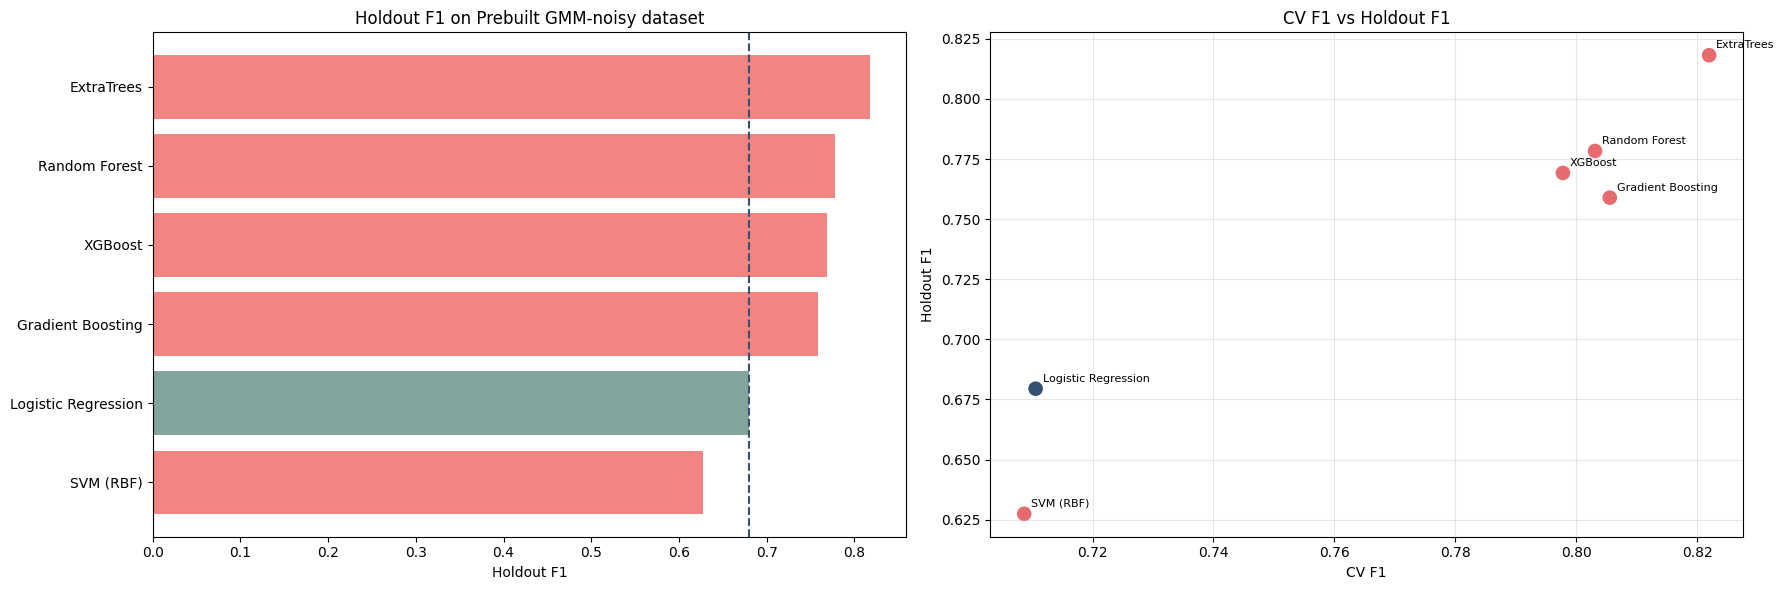

In [11]:
proposed_ranked = final_results[
    (final_results["Category"] == "Proposed Extension")
    & (final_results["Holdout F1"].notna())
].sort_values(["Holdout F1", "CV F1"], ascending=[False, False]).reset_index(drop=True)

TOP3_PROPOSED_MODELS = proposed_ranked.head(3).copy()
TOP3_PROPOSED_MODELS.insert(0, "Rank", np.arange(1, len(TOP3_PROPOSED_MODELS) + 1))

top3_tuning_rows = []
for _, row in TOP3_PROPOSED_MODELS.iterrows():
    matching_spec = next(
        (spec for spec in PROPOSED_MODEL_SPECS if spec["model"] == row["Model"]),
        None,
    )
    registry_key = None if matching_spec is None else f"{matching_spec['registry_key']}::{PRIMARY_NOISE_VARIANT}"
    search_obj = None if registry_key is None else SEARCH_REGISTRY.get(registry_key)

    top3_tuning_rows.append(
        {
            "Rank": int(row["Rank"]),
            "Model": row["Model"],
            "Search Scoring": None if matching_spec is None else matching_spec.get("search_scoring", "n/a"),
            "Best CV Search Score": np.nan if search_obj is None else float(search_obj.best_score_),
            "Best Params": None if search_obj is None else json.dumps(search_obj.best_params_, sort_keys=True),
            "Holdout Accuracy": row["Holdout Accuracy"],
            "Holdout F1": row["Holdout F1"],
            "Holdout ROC-AUC": row["Holdout ROC-AUC"],
        }
    )

TOP3_TUNING_SUMMARY = pd.DataFrame(top3_tuning_rows)

display(TOP3_PROPOSED_MODELS[["Rank", "Model", "CV Accuracy", "CV F1", "Holdout Accuracy", "Holdout F1", "Holdout ROC-AUC"]])
display(TOP3_TUNING_SUMMARY)

noisy_model_comparison = final_results[
    final_results["Holdout F1"].notna()
].sort_values("Holdout F1", ascending=True)

primary_benchmark = noisy_model_comparison[
    noisy_model_comparison["Category"] == "Literature Benchmark"
].iloc[0]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

axes[0].barh(
    noisy_model_comparison["Model"],
    noisy_model_comparison["Holdout F1"],
    color=["#84a59d" if category == "Literature Benchmark" else "#f28482" for category in noisy_model_comparison["Category"]],
)
axes[0].axvline(primary_benchmark["Holdout F1"], color="#355070", linestyle="--", linewidth=1.5)
axes[0].set_title(f"Holdout F1 on {PRIMARY_NOISE_VARIANT}")
axes[0].set_xlabel("Holdout F1")

axes[1].scatter(
    noisy_model_comparison["CV F1"],
    noisy_model_comparison["Holdout F1"],
    s=90,
    c=["#355070" if category == "Literature Benchmark" else "#e56b6f" for category in noisy_model_comparison["Category"]],
)
for _, row in noisy_model_comparison.iterrows():
    axes[1].annotate(
        row["Model"],
        (row["CV F1"], row["Holdout F1"]),
        textcoords="offset points",
        xytext=(5, 5),
        fontsize=8,
    )
axes[1].set_title("CV F1 vs Holdout F1")
axes[1].set_xlabel("CV F1")
axes[1].set_ylabel("Holdout F1")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 11. Findings and Interpretation

The summary below is generated from the refreshed results table so the narrative updates automatically when the notebook is rerun.


In [12]:
primary_noisy_benchmark = final_results[
    (final_results["Category"] == "Literature Benchmark")
    & (final_results["Dataset Variant"] == PRIMARY_NOISE_VARIANT)
].iloc[0]

available_proposed = final_results[
    (final_results["Category"] == "Proposed Extension")
    & (final_results["Dataset Variant"] == PRIMARY_NOISE_VARIANT)
    & (final_results["Holdout F1"].notna())
]

best_proposed = available_proposed.iloc[0] if not available_proposed.empty else None
best_accuracy_row = final_results[final_results["Holdout Accuracy"].notna()].sort_values(
    by=["Holdout Accuracy", "Holdout F1"],
    ascending=[False, False],
).iloc[0]

tuned_models_used = final_results[
    (final_results["Tuned"] == "Yes") & (final_results["Holdout F1"].notna())
]["Model"].tolist()
primary_gap = FINAL_MODEL_DIFFERENCES[
    FINAL_MODEL_DIFFERENCES["Priority"] == "Primary remaining difference"
]["Aspect"].tolist()
secondary_gaps = FINAL_MODEL_DIFFERENCES[
    FINAL_MODEL_DIFFERENCES["Priority"] == "Secondary"
]["Aspect"].tolist()
top3_names = TOP3_PROPOSED_MODELS["Model"].tolist()

if best_proposed is None:
    proposed_text = "No proposed extension completed successfully on the noisy dataset."
else:
    recovery_margin = best_proposed["Holdout F1"] - primary_noisy_benchmark["Holdout F1"]
    relation = "exceeded" if recovery_margin > 0 else "did not exceed"
    proposed_text = (
        f"The strongest noisy-data recovery model was **{best_proposed['Model']}** "
        f"with Holdout Accuracy = **{best_proposed['Holdout Accuracy']:.4f}**, Holdout F1 = "
        f"**{best_proposed['Holdout F1']:.4f}**, and Holdout ROC-AUC = **{best_proposed['Holdout ROC-AUC']:.4f}**. "
        f"Relative to the literature benchmark on the same noisy dataset, it **{relation}** the benchmark by "
        f"**{abs(recovery_margin):.4f} Holdout F1**."
    )

interpretation_md = f"""
### Interpretation Summary

- **Dataset source:** Notebook 06 now starts directly from **`{DATASET_PATH.name}`** and excludes `Synthetic_Flag` from the model features, matching the data entry point of `final_models.ipynb`.
- **Main remaining difference:** The strongest remaining protocol mismatch is **{', '.join(primary_gap)}**.
- **Secondary differences:** The notebook still differs on **{'; '.join(secondary_gaps)}**, but these are treated as secondary rather than the first explanation for performance gaps.
- **Noisy-dataset benchmark:** The clean-literature winner re-evaluated on the noisy dataset achieved **Holdout Accuracy = {primary_noisy_benchmark['Holdout Accuracy']:.4f}**, **Holdout F1 = {primary_noisy_benchmark['Holdout F1']:.4f}**, and **Holdout ROC-AUC = {primary_noisy_benchmark['Holdout ROC-AUC']:.4f}**.
- **Best recovery model:** {proposed_text}
- **Highest raw holdout accuracy:** The top raw holdout-accuracy row in this notebook is **{best_accuracy_row['Model']}** with **Accuracy = {best_accuracy_row['Holdout Accuracy']:.4f}** and **F1 = {best_accuracy_row['Holdout F1']:.4f}**.
- **Integrated top-3 tuning:** The notebook now exposes the tuned top 3 proposed models directly in a dedicated section: **{', '.join(top3_names)}**.
- **Tuned models evaluated:** **{', '.join(tuned_models_used)}**.
"""

display(Markdown(interpretation_md))



### Interpretation Summary

- **Dataset source:** Notebook 06 now starts directly from **`ILPD_robust_scaled_with_gmm_noise.csv`** and excludes `Synthetic_Flag` from the model features, matching the data entry point of `final_models.ipynb`.
- **Main remaining difference:** The strongest remaining protocol mismatch is **SMOTE ordering**.
- **Secondary differences:** The notebook still differs on **Feature selection; Missing-value handling; Model families; Search objective**, but these are treated as secondary rather than the first explanation for performance gaps.
- **Noisy-dataset benchmark:** The clean-literature winner re-evaluated on the noisy dataset achieved **Holdout Accuracy = 0.6350**, **Holdout F1 = 0.6795**, and **Holdout ROC-AUC = 0.7627**.
- **Best recovery model:** The strongest noisy-data recovery model was **ExtraTrees** with Holdout Accuracy = **0.7372**, Holdout F1 = **0.8182**, and Holdout ROC-AUC = **0.7696**. Relative to the literature benchmark on the same noisy dataset, it **exceeded** the benchmark by **0.1387 Holdout F1**.
- **Highest raw holdout accuracy:** The top raw holdout-accuracy row in this notebook is **ExtraTrees** with **Accuracy = 0.7372** and **F1 = 0.8182**.
- **Integrated top-3 tuning:** The notebook now exposes the tuned top 3 proposed models directly in a dedicated section: **ExtraTrees, Random Forest, XGBoost**.
- **Tuned models evaluated:** **ExtraTrees, Random Forest, XGBoost, Gradient Boosting, SVM (RBF)**.


## 12. Closing Note

Notebook 06 now stays entirely inside the noisy-data setting by starting from the prebuilt GMM-noisy dataset artifact. That makes its benchmark and tuning results easier to compare against `final_models.ipynb`, while the remaining protocol differences are surfaced explicitly instead of being hidden inside the workflow.


## 13. HTML Report Export

Generate an HTML version of this notebook in `produced_reports/` for quick review and archiving.


In [13]:
import importlib.util
import shutil
import subprocess
import sys

HTML_DIR = ROOT / "produced_reports"
HTML_DIR.mkdir(parents=True, exist_ok=True)

NOTEBOOK_PATH = ROOT / "scripts" / "06_gmm_noise_extension_cleaned_ilpd.ipynb"
OUTPUT_PATH = HTML_DIR / NOTEBOOK_PATH.with_suffix('.html').name

export_commands = []

if importlib.util.find_spec("nbconvert") is not None:
    export_commands.append([
        sys.executable, "-m", "nbconvert",
        "--to", "html",
        str(NOTEBOOK_PATH),
        "--output-dir", str(HTML_DIR),
    ])

jupyter_nbconvert_cmd = shutil.which("jupyter-nbconvert")
if jupyter_nbconvert_cmd:
    export_commands.append([
        jupyter_nbconvert_cmd,
        "--to", "html",
        str(NOTEBOOK_PATH),
        "--output-dir", str(HTML_DIR),
    ])

jupyter_cmd = shutil.which("jupyter")
if jupyter_cmd:
    export_commands.append([
        jupyter_cmd, "nbconvert",
        "--to", "html",
        str(NOTEBOOK_PATH),
        "--output-dir", str(HTML_DIR),
    ])

attempt_errors = []
for command in export_commands:
    try:
        subprocess.run(command, check=True)
        print(f"Exported HTML to: {OUTPUT_PATH}")
        break
    except Exception as exc:
        attempt_errors.append({"command": command, "error": repr(exc)})
else:
    print("HTML export skipped because nbconvert is unavailable in the active notebook environment.")
    print(f"Save the notebook, install nbconvert in the same kernel environment, and rerun this cell. Target path: {OUTPUT_PATH}")
    if attempt_errors:
        print(attempt_errors)


[NbConvertApp] Converting notebook /Users/samyabrataroy/Downloads/Spring_Internship_2026/scripts/06_gmm_noise_extension_cleaned_ilpd.ipynb to html


Exported HTML to: /Users/samyabrataroy/Downloads/Spring_Internship_2026/produced_reports/06_gmm_noise_extension_cleaned_ilpd.html


[NbConvertApp] WARNING | Alternative text is missing on 1 image(s).
[NbConvertApp] Writing 548888 bytes to /Users/samyabrataroy/Downloads/Spring_Internship_2026/produced_reports/06_gmm_noise_extension_cleaned_ilpd.html
